<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

<ipython-input-2-d0a9b3af8ed0>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


#### Read the dataset in the csv file from the URL


In [3]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [4]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


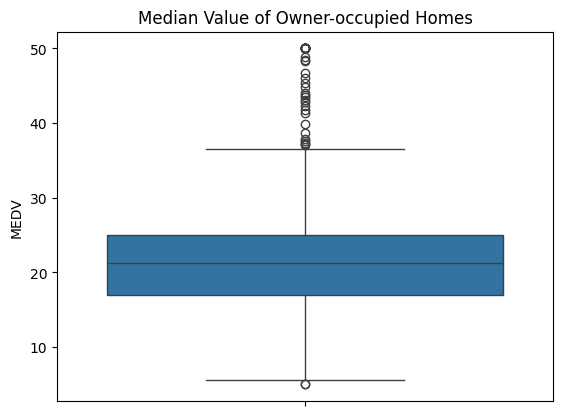

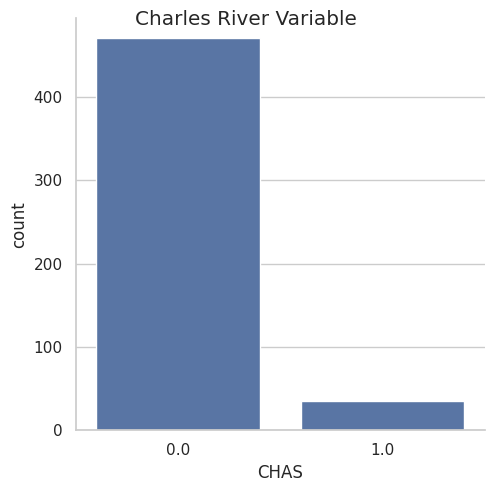

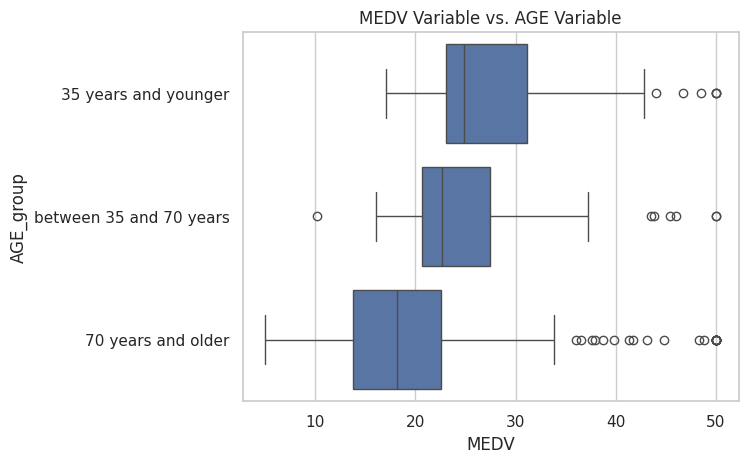

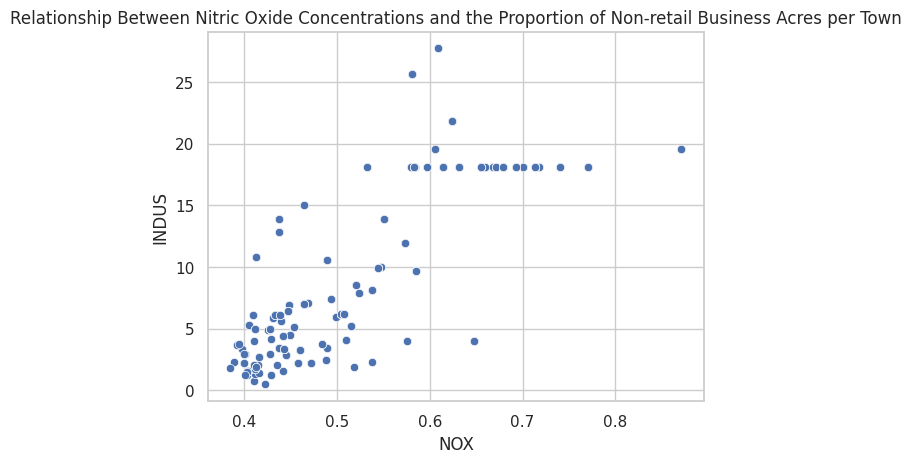

There appears to be a weak positive correlation between Nitric oxide concentrations and the proportion of non-retail business acres per town.


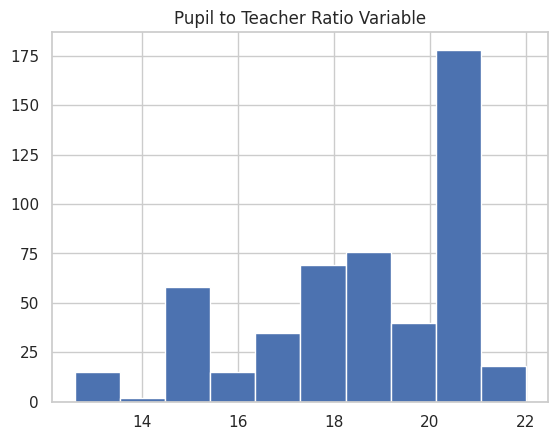

<ipython-input-5-01d36d151f33>:32: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax6 = sns.distplot(boston_df['MEDV'],


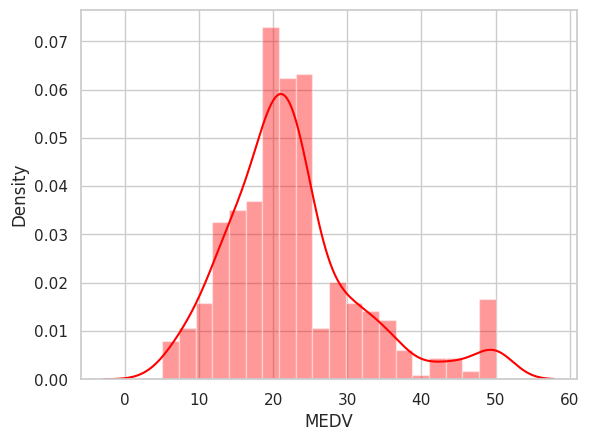

H_0: µ_1 = µ_2 ("There is no significant difference in median value of houses bounded by the Charles river")
H_1: µ_1 ≠ µ_2 ("There is a significant difference in median value of houses bounded by the Charles river")
LeveneResult(statistic=8.75190489604598, pvalue=0.003238119367639829)
TtestResult(statistic=-3.113291312794837, pvalue=0.003567170098137517, df=36.876408797611994)
Since the p-value is less than α = 0.05, we reject the null hypothesis as there is enough proof that there is a statisical difference in the median value of houses bounded by the Charles river.
H_0: µ_1 = µ_2 = µ_3 (the three population means are equal)
H_1: At least one of the means differ
LeveneResult(statistic=2.7806200293748304, pvalue=0.06295337343259205)
F_Statistic: 36.40764999196599, P-Value: 1.7105011022702984e-15
Since the p-value is less than 0.05, we will reject the null hypothesis as there is significant evidence that at least one of the means differ.
H_0: Nitric oxide concentrations are not correla

In [5]:
# "Median Value of owner-occupied homes" boxplot
ax = sns.boxplot(y = 'MEDV', data = boston_df)
ax.set_title('Median Value of Owner-occupied Homes')
pyplot.show()

# Charles River variable bar plot
sns.set(style = "whitegrid")
ax2 = sns.catplot(x = 'CHAS', kind = 'count', data = boston_df)
ax2.fig.suptitle('Charles River Variable')
pyplot.show()

# MEDV variable vs. AGE variable boxplot
boston_df.loc[(boston_df['AGE'] <= 35), 'AGE_group'] = '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35)&(boston_df['AGE'] < 70), 'AGE_group'] = 'between 35 and 70 years'
boston_df.loc[(boston_df['AGE'] >= 70), 'AGE_group'] = '70 years and older'
ax3 = sns.boxplot(x = 'MEDV', y = 'AGE_group', order = ['35 years and younger', 'between 35 and 70 years', '70 years and older'], data = boston_df)
ax3.set_title('MEDV Variable vs. AGE Variable')
pyplot.show()

# Relationship between Nitric oxide concentrations and proportion of non-retail business acres per town scatter plot
ax4 = sns.scatterplot(x = 'NOX', y = 'INDUS', data = boston_df)
ax4.set_title('Relationship Between Nitric Oxide Concentrations and the Proportion of Non-retail Business Acres per Town')
pyplot.show()
print('There appears to be a weak positive correlation between Nitric oxide concentrations and the proportion of non-retail business acres per town.')

# Pupil to teacher ratio variable histogram
ax5 = pyplot.hist(boston_df['PTRATIO'])
pyplot.title('Pupil to Teacher Ratio Variable')
pyplot.show()

# Is there a significant difference in median value of houses bounded by the Charles river or not? (T-test for independent samples)
ax6 = sns.distplot(boston_df['MEDV'],
                  bins = 20,
                  kde = True,
                  color = 'red')
ax.set(xlabel = 'Normal Distribution', ylabel = 'Frequency')
pyplot.show()
print('H_0: µ_1 = µ_2 ("There is no significant difference in median value of houses bounded by the Charles river")')
print('H_1: µ_1 ≠ µ_2 ("There is a significant difference in median value of houses bounded by the Charles river")')
levene = scipy.stats.levene(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                   boston_df[boston_df['CHAS'] == 1]['MEDV'], center = 'mean')
print(levene)
# Since the p-value is less than α = 0.05 we can assume inequality of variance
ttest = scipy.stats.ttest_ind(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                      boston_df[boston_df['CHAS'] == 1]['MEDV'], equal_var = False)
print(ttest)
print('Since the p-value is less than α = 0.05, we reject the null hypothesis as there is enough proof that there is a statisical difference in the median value of houses bounded by the Charles river.')

# Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)? (ANOVA)
print('H_0: µ_1 = µ_2 = µ_3 (the three population means are equal)')
print('H_1: At least one of the means differ')
levene2 = scipy.stats.levene(boston_df[boston_df['AGE_group'] == '35 years and younger']['MEDV'],
                   boston_df[boston_df['AGE_group'] == 'between 35 and 70 years']['MEDV'],
                   boston_df[boston_df['AGE_group'] == '70 years and older']['MEDV'],
                   center = 'mean')
print(levene2)
# Since the p-value is greater than α = 0.05 we can assume equality of variance
thirtyfive_lower = boston_df[boston_df['AGE_group'] == '35 years and younger']['MEDV']
thirtyfive_seventy = boston_df[boston_df['AGE_group'] == 'between 35 and 70 years']['MEDV']
seventy_older = boston_df[boston_df['AGE_group'] == '70 years and older']['MEDV']
f_statistic, p_value = scipy.stats.f_oneway(thirtyfive_lower, thirtyfive_seventy, seventy_older)
print("F_Statistic: {0}, P-Value: {1}".format(f_statistic, p_value))
print('Since the p-value is less than 0.05, we will reject the null hypothesis as there is significant evidence that at least one of the means differ.')

# Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town? 
# (Pearson Correlation)
print('H_0: Nitric oxide concentrations are not correlated with the proportion of non-retail business acres per town')
print('H_1: Nitric oxide concentrations are correlated with the proportion of non-retail business acres per town')
pearson = scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])
print(pearson)
print('Since the p-value (Sig. (2-tailed)) < 0.05, we reject the Null hypothesis and conclude that there exists a correlation between Nitric Oxide concentrations and the proportion of non-retail business acres per town.')

# What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes? 
# (Regression analysis)
print('H_0: β1 = 0 (There is no impact of an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes)')
print('H_1: β1 ≠ 0 (There is an impact of an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes)')
X = boston_df['DIS']
y = boston_df['MEDV']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

print(model.summary())
print('Since the p-value is less than the alpha value of 0.05, we reject the null hypothesis as there is evidence that there is an impact of an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes.')
print('The impact is measured by a coefficient of 1.0916')